## K-means 

Przeprowadzone eksperymenty z algorytmem K-Means na zbiorze Wine wykazały, że dane tworzą dobrze rozdzielone skupiska, szczególnie przy liczbie klastrów k=2, dla której uzyskano najwyższą wartość wskaźnika silhouette (około 0.66). Dla k=3 i większych wartości k jakość grupowania pozostaje na przyzwoitym poziomie, jednak silhouette jest niższy, co sugeruje, że dodatkowe klastry wprowadzają bardziej subtelne podziały, nie poprawiając wyników. Zastosowanie PCA do redukcji wymiarowości do 2 i 3 wymiarów nie pogorszyło jakości grupowania. Wartości silhouette dla PCA 2D i PCA 3D są bardzo zbliżone.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine
import warnings
warnings.filterwarnings('ignore')

data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['proline'] = y
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

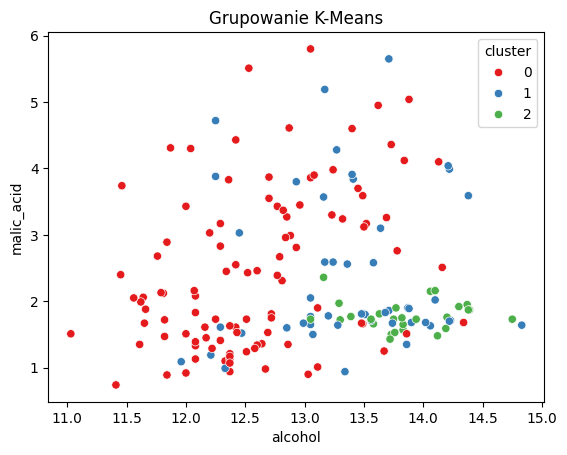

cluster   0   1   2
proline            
0         1  31  27
1        64   7   0
2        37  11   0


In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_
sns.scatterplot(x=df[feature_names[0]], y=df[feature_names[1]], hue=df['cluster'], palette='Set1')
plt.title('Grupowanie K-Means')
plt.show()
print(pd.crosstab(df['proline'], df['cluster']))

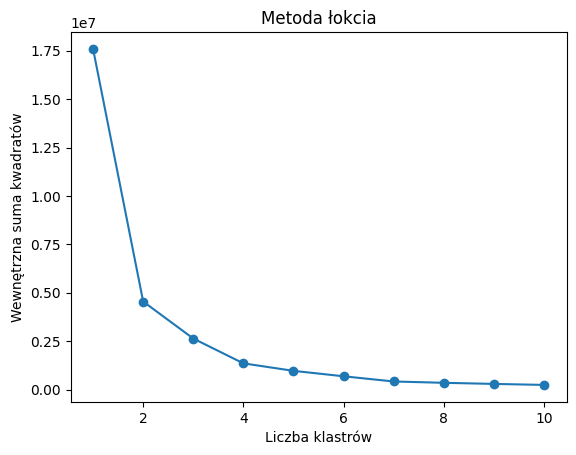

In [46]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Liczba klastrów')
plt.ylabel('Wewnętrzna suma kwadratów')
plt.title('Metoda łokcia')
plt.show()

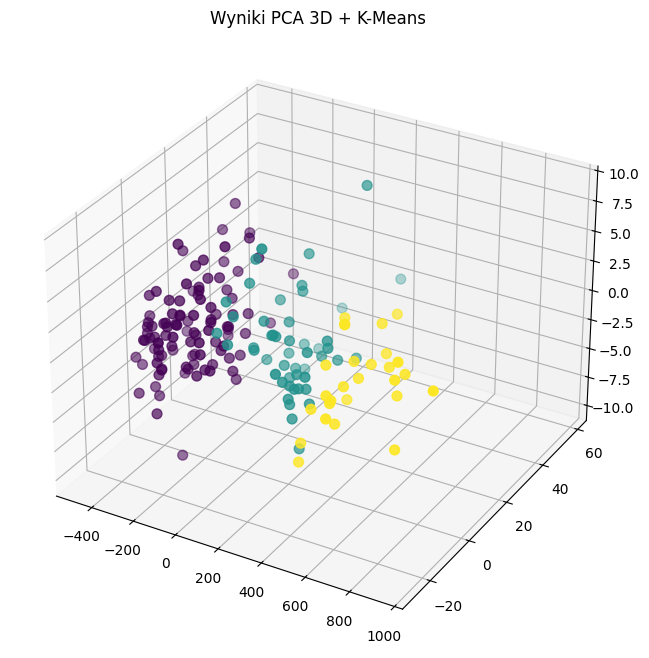

In [47]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)
df['PCA1'] = X_pca_3d[:, 0]
df['PCA2'] = X_pca_3d[:, 1]
df['PCA3'] = X_pca_3d[:, 2]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['PCA1'], df['PCA2'], df['PCA3'], s=50, cmap='viridis', c=df['cluster'])
plt.title("Wyniki PCA 3D + K-Means")
plt.show()


Liczba klastrów: 2, Silhouette Score: 0.6569
Liczba klastrów: 3, Silhouette Score: 0.5596
Liczba klastrów: 4, Silhouette Score: 0.5669
Liczba klastrów: 5, Silhouette Score: 0.5082
Liczba klastrów: 6, Silhouette Score: 0.5422
Liczba klastrów: 7, Silhouette Score: 0.5595
Liczba klastrów: 8, Silhouette Score: 0.5289
Liczba klastrów: 9, Silhouette Score: 0.5052
Liczba klastrów: 10, Silhouette Score: 0.5106


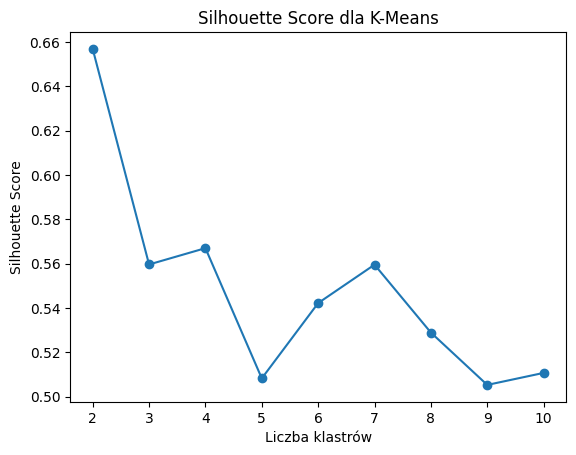

In [48]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans_silhouette = KMeans(n_clusters=k, random_state=42)
    kmeans_silhouette.fit(X)
    score = silhouette_score(X, kmeans_silhouette.labels_)
    silhouette_scores.append(score)
    print(f'Liczba klastrów: {k}, Silhouette Score: {score:.4f}')

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Liczba klastrów')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score dla K-Means')
plt.show()

In [ ]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)
silhouette = []
silhouette_pca2 = []
silhouette_pca3 = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    silhouette.append(silhouette_score(X, kmeans.labels_))
    kmeans_pca2 = KMeans(n_clusters=k, random_state=42)
    kmeans_pca2.fit(X_pca)
    silhouette_pca2.append(silhouette_score(X_pca, kmeans_pca2.labels_))
    kmeans_pca3 = KMeans(n_clusters=k, random_state=42)
    kmeans_pca3.fit(X_pca_3d)
    silhouette_pca3.append(silhouette_score(X_pca_3d, kmeans_pca3.labels_))
    print(f"k={k}: Silhouette ={silhouette[-1]:.4f}, PCA2={silhouette_pca2[-1]:.4f}, PCA3={silhouette_pca3[-1]:.4f}")

k=2: Silhouette =0.6569, PCA2=0.6572, PCA3=0.6570
k=3: Silhouette =0.5596, PCA2=0.5603, PCA3=0.5599
k=4: Silhouette =0.5669, PCA2=0.5682, PCA3=0.5675
k=5: Silhouette =0.5082, PCA2=0.5655, PCA3=0.5091
k=6: Silhouette =0.5422, PCA2=0.5678, PCA3=0.5436
k=7: Silhouette =0.5595, PCA2=0.5617, PCA3=0.5609
k=8: Silhouette =0.5289, PCA2=0.5325, PCA3=0.5305
k=9: Silhouette =0.5052, PCA2=0.5102, PCA3=0.5074
k=10: Silhouette =0.5106, PCA2=0.5165, PCA3=0.5132


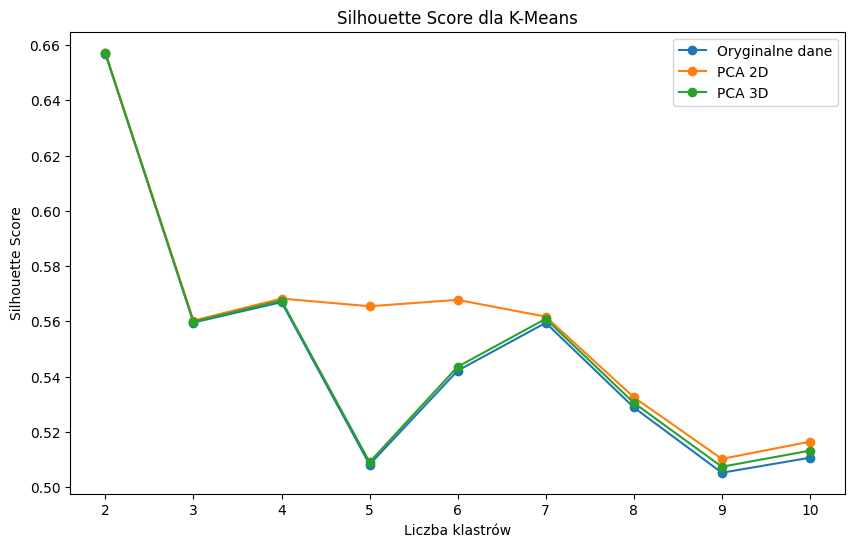

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(2, 11), silhouette, marker='o', label='Oryginalne dane')
ax.plot(range(2, 11), silhouette_pca2, marker='o', label='PCA 2D')
ax.plot(range(2, 11), silhouette_pca3, marker='o', label='PCA 3D')
ax.set_xlabel('Liczba klastrów')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score dla K-Means')
ax.legend()
plt.show()